In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("ai_job_impact.csv")
print(df.head())
print(df.shape)
print(df.isnull().sum())

  Employee_ID  Age  Gender Education_Level       Industry           Job_Role  \
0       E0001   50  Female        Bachelor      Marketing    Content Creator   
1       E0002   45    Male     High School  Manufacturing  Quality Inspector   
2       E0003   51  Female          Master             IT    DevOps Engineer   
3       E0004   48    Male             PhD      Education            Teacher   
4       E0005   24    Male        Bachelor     Healthcare             Doctor   

   Years_Experience AI_Adoption_Level Automation_Risk Upskilling_Required  \
0                26              High            High                 Yes   
1                19               Low             Low                 Yes   
2                28            Medium          Medium                 Yes   
3                24            Medium          Medium                 Yes   
4                 0              High          Medium                  No   

   Salary_Before_AI  Salary_After_AI Job_Status  Work_Ho

In [52]:
df["Cambio_Salario_%"] = (df["Salary_After_AI"] - df["Salary_Before_AI"]) / df["Salary_Before_AI"] * 100
df["Grupo_edad"] = pd.cut(df["Age"], bins=[0, 30, 45, 60], labels=["Joven", "Adulto", "Senior"])

In [53]:
print(df.head())

  Employee_ID  Age  Gender Education_Level       Industry           Job_Role  \
0       E0001   50  Female        Bachelor      Marketing    Content Creator   
1       E0002   45    Male     High School  Manufacturing  Quality Inspector   
2       E0003   51  Female          Master             IT    DevOps Engineer   
3       E0004   48    Male             PhD      Education            Teacher   
4       E0005   24    Male        Bachelor     Healthcare             Doctor   

   Years_Experience AI_Adoption_Level Automation_Risk Upskilling_Required  \
0                26              High            High                 Yes   
1                19               Low             Low                 Yes   
2                28            Medium          Medium                 Yes   
3                24            Medium          Medium                 Yes   
4                 0              High          Medium                  No   

   Salary_Before_AI  Salary_After_AI Job_Status  Work_Ho

In [54]:
print(df["Job_Status"].value_counts())
print(df.groupby("Industry")["Cambio_Salario_%"].mean())
print(df.pivot_table(values="Cambio_Salario_%", index="Industry", columns="AI_Adoption_Level"))

Job_Status
Unchanged    1093
Modified      801
Replaced      106
Name: count, dtype: int64
Industry
Education        6.063224
Finance          5.233065
Healthcare       7.591661
IT               6.225764
Manufacturing    4.696661
Marketing        6.080251
Retail           6.625069
Name: Cambio_Salario_%, dtype: float64
AI_Adoption_Level       High       Low    Medium
Industry                                        
Education           9.397867  2.393857  5.503197
Finance             9.124468  2.367485  4.002358
Healthcare         12.068028  3.345951  5.215102
IT                 12.197613  2.344942  4.695288
Manufacturing       7.977831  2.605193  3.769493
Marketing          10.324806  2.688362  4.638369
Retail             11.569811  2.146276  5.339210


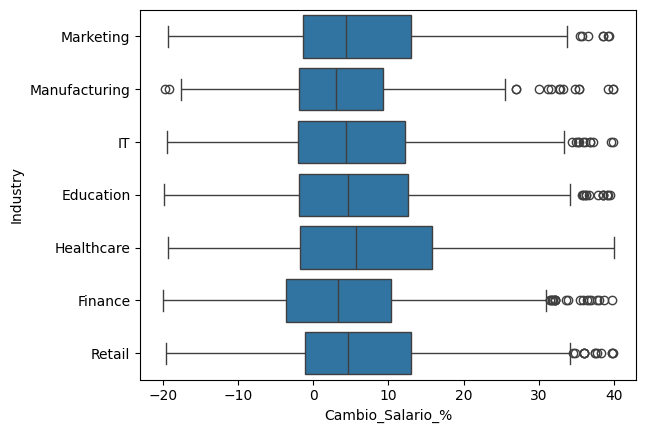

In [55]:
sns.boxplot(x="Cambio_Salario_%", y="Industry", data=df)
plt.show()
#

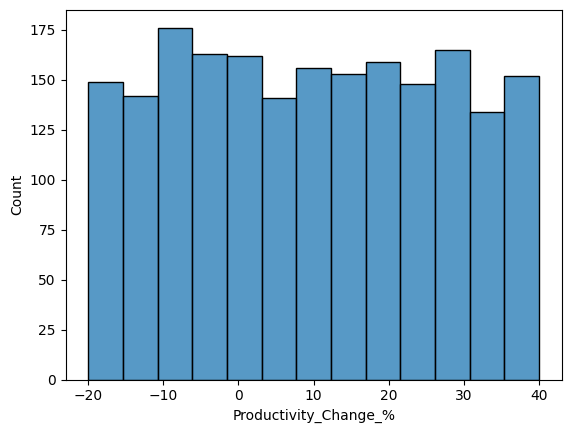

In [56]:
sns.histplot(data=df, x="Productivity_Change_%",)
plt.show()

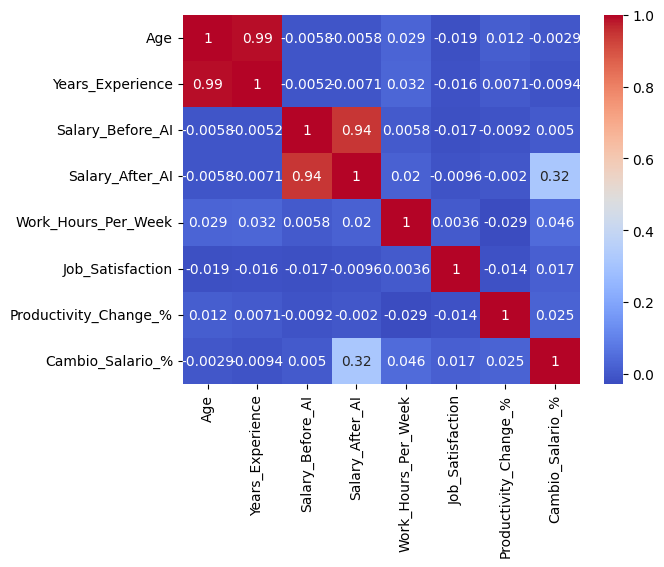

In [57]:
Correlaciones = df.corr(numeric_only=True)
sns.heatmap(Correlaciones, annot=True, cmap="coolwarm")
plt.show()

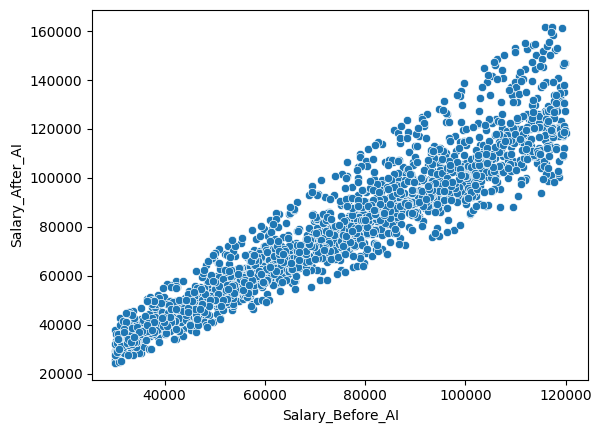

In [58]:
sns.scatterplot(data=df, x="Salary_Before_AI", y="Salary_After_AI")
plt.show()

In [59]:
print(df["Job_Status"].mode())

0    Unchanged
Name: Job_Status, dtype: object


In [60]:
print(df["AI_Adoption_Level"].mode())

0    High
Name: AI_Adoption_Level, dtype: object


In [61]:
Tipo_de_industria = pd.DataFrame({
    "Industry": ['Marketing', 'Manufacturing', 'IT', 'Education', 'Healthcare', 'Finance', 'Retail'],
    "Tipo de industria": ["Servicios", "Tecnica", "Tecnica", "Servicios", "Servicios", "Servicios", "Servicios"] # Placeholder classification
})

In [62]:
df = pd.merge(df, Tipo_de_industria, on = "Industry", how = "left")

In [63]:
display(df.head())

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%,Cambio_Salario_%,Grupo_edad,Tipo de industria
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,-10.639393,Senior,Servicios
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,-2.857104,Adulto,Tecnica
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,19.764379,Senior,Tecnica
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,-5.815965,Senior,Servicios
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,20.817350,Joven,Servicios


In [64]:
display(df.head())

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%,Cambio_Salario_%,Grupo_edad,Tipo de industria
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64,-10.639393,Senior,Servicios
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05,-2.857104,Adulto,Tecnica
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05,19.764379,Senior,Tecnica
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47,-5.815965,Senior,Servicios
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03,20.817350,Joven,Servicios


Ahora, vamos a limpiar las columnas duplicadas para que tu DataFrame sea más fácil de manejar.

In [66]:
# Calcular el número total de empleos por industria
total_jobs_by_industry = df['Industry'].value_counts().reset_index()
total_jobs_by_industry.columns = ['Industry', 'Total_Jobs']

# Filtrar los empleos 'Replaced'
replaced_jobs = df[df['Job_Status'] == 'Replaced']

# Contar los empleos 'Replaced' por industria
replaced_jobs_by_industry = replaced_jobs['Industry'].value_counts().reset_index()
replaced_jobs_by_industry.columns = ['Industry', 'Replaced_Jobs']

# Unir los dos DataFrames para calcular la proporción
industry_impact = pd.merge(total_jobs_by_industry, replaced_jobs_by_industry, on='Industry', how='left')
industry_impact['Replaced_Proportion'] = (industry_impact['Replaced_Jobs'] / industry_impact['Total_Jobs']) * 100

# Reemplazar NaN con 0 en caso de que alguna industria no tenga empleos 'Replaced'
industry_impact['Replaced_Proportion'] = industry_impact['Replaced_Proportion'].fillna(0)

# Ordenar por la proporción de empleos 'Replaced' de forma descendente
industry_impact_sorted = industry_impact.sort_values(by='Replaced_Proportion', ascending=False)

print("Proporción de empleos 'Replaced' por industria:")
display(industry_impact_sorted)

# Identificar la industria con la mayor proporción
most_impacted_industry = industry_impact_sorted.iloc[0]
print(f"\nLa industria con la mayor proporción de empleos 'Replaced' es: {most_impacted_industry['Industry']} con un {most_impacted_industry['Replaced_Proportion']:.2f}% de empleos 'Replaced'.")

Proporción de empleos 'Replaced' por industria:


,Industry,Total_Jobs,Replaced_Jobs,Replaced_Proportion
4,Marketing,273,19,6.959707
3,Education,293,18,6.143345
0,Finance,300,18,6.000000
1,IT,298,16,5.369128
5,Retail,271,13,4.797048
6,Healthcare,270,11,4.074074
2,Manufacturing,295,11,3.728814



La industria con la mayor proporción de empleos 'Replaced' es: Marketing con un 6.96% de empleos 'Replaced'.


In [67]:
salary_change_by_ai_adoption = df.groupby('AI_Adoption_Level')['Cambio_Salario_%'].mean().sort_values(ascending=False)

print("Cambio salarial promedio por nivel de adopción de IA:")
display(salary_change_by_ai_adoption)

# Interpretar los resultados
if 'High' in salary_change_by_ai_adoption.index and 'Low' in salary_change_by_ai_adoption.index:
    if salary_change_by_ai_adoption['High'] > salary_change_by_ai_adoption['Low']:
        print("\nSí, parece que una alta adopción de IA se asocia con un mayor aumento salarial en promedio.")
    else:
        print("\nNo, una alta adopción de IA no parece asociarse con un mayor aumento salarial en promedio.")
elif 'High' in salary_change_by_ai_adoption.index:
    print(f"\nEl cambio salarial promedio para la alta adopción de IA es: {salary_change_by_ai_adoption['High']:.2f}%")
else:
    print("\nNo hay suficientes datos para los niveles 'High' o 'Low' de adopción de IA para hacer una comparación directa.")

Cambio salarial promedio por nivel de adopción de IA:


,Cambio_Salario_%
AI_Adoption_Level,
High,10.411136
Medium,4.713187
Low,2.526875



Sí, parece que una alta adopción de IA se asocia con un mayor aumento salarial en promedio.


In [68]:
print(df, "Automation_Risk", "Job_Status")

     Employee_ID  Age  Gender Education_Level       Industry  \
0          E0001   50  Female        Bachelor      Marketing   
1          E0002   45    Male     High School  Manufacturing   
2          E0003   51  Female          Master             IT   
3          E0004   48    Male             PhD      Education   
4          E0005   24    Male        Bachelor     Healthcare   
...          ...  ...     ...             ...            ...   
1995       E1996   55   Other             PhD     Healthcare   
1996       E1997   31    Male             PhD        Finance   
1997       E1998   43  Female        Bachelor         Retail   
1998       E1999   43  Female        Bachelor      Marketing   
1999       E2000   23   Other          Master      Marketing   

                Job_Role  Years_Experience AI_Adoption_Level Automation_Risk  \
0        Content Creator                26              High            High   
1      Quality Inspector                19               Low           

<Axes: xlabel='Cambio_Salario_%', ylabel='AI_Adoption_Level'>

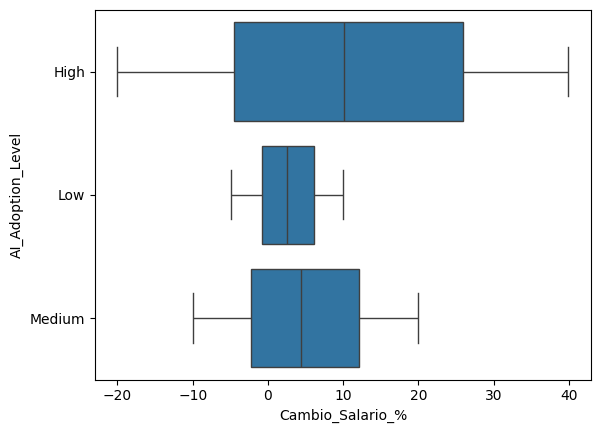

In [69]:
sns.boxplot(data=df, x="Cambio_Salario_%", y="AI_Adoption_Level")

In [82]:
df = pd.merge(df, replaced_jobs_by_industry, on='Industry', how='left')
df = df.rename(columns={'Empleos_relplaced_por_Industria': 'Empleos_Replaced_por_Industria'})
display(df.head())

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,...,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%,Cambio_Salario_%,Grupo_edad,Tipo de industria,Empleos_Replaced_por_Industria,Empleos_Replaced_por_Industria,Replaced_Jobs
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,...,45,No,5,-10.64,-10.639393,Senior,Servicios,19,19,19
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,...,36,Yes,6,19.05,-2.857104,Adulto,Tecnica,11,11,11
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,...,46,Yes,3,17.05,19.764379,Senior,Tecnica,16,16,16
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,...,50,No,9,-2.47,-5.815965,Senior,Servicios,18,18,18
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,...,52,Yes,6,7.03,20.817350,Joven,Servicios,11,11,11


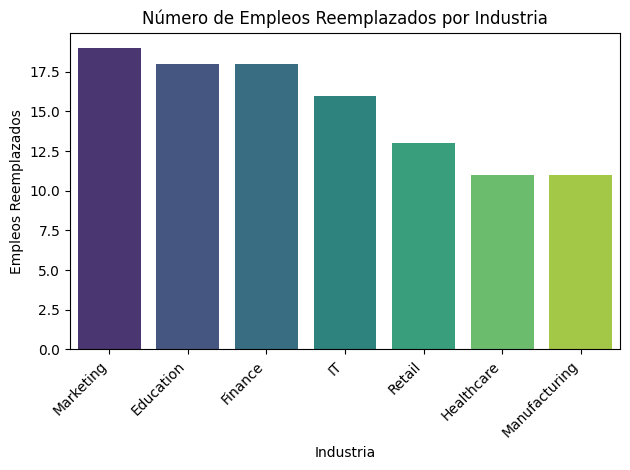

In [86]:
sns.barplot(data=industry_impact_sorted, x="Industry", y="Replaced_Jobs", hue="Industry", palette='viridis', legend=False)
plt.xlabel('Industria')
plt.ylabel('Empleos Reemplazados')
plt.title('Número de Empleos Reemplazados por Industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Con base en los datos, una mayor adopción de IA se asocia con aumentos salariales: el cambio promedio es de 2,53 % con adopción baja, 4,71 % con media y 10,41 % con alta. Sin embargo, la adopción alta también aumenta la dispersión, y una parte de los trabajadores presenta cambios negativos. En cuanto a los puestos reemplazados, representan un 5,3 % del total. Marketing (6,96 %), educación (6,14 %) y finanzas (6,00 %) son los sectores con mayor proporción, pero las diferencias frente al resto son pequeñas. Estos resultados deben tomarse con cautela: la distribución plana de la productividad, los límites exactos en los rangos de cambio salarial y el hecho de que el reemplazo solo ocurra con adopción y riesgo altos indican que los datos probablemente son artificiales, por lo que no pueden aplicarse al mercado laboral real.